# Flow-Matching

A easy fm demo to fit some kinds of distribution, major components are:

- Sample Distribution: Mainly Gaussian: $f(x)=\frac{1}{\sigma \sqrt{2\pi}}\exp(-(x-\mu)^2/2\sigma^2)$
- Target Distribution: Predefined or Unknown Distribution.
- Denoise Network: Denoise noise sample from Sample Distribution to Target Distribution. In this eg we use MLP.

Matplotlib is building the font cache; this may take a moment.


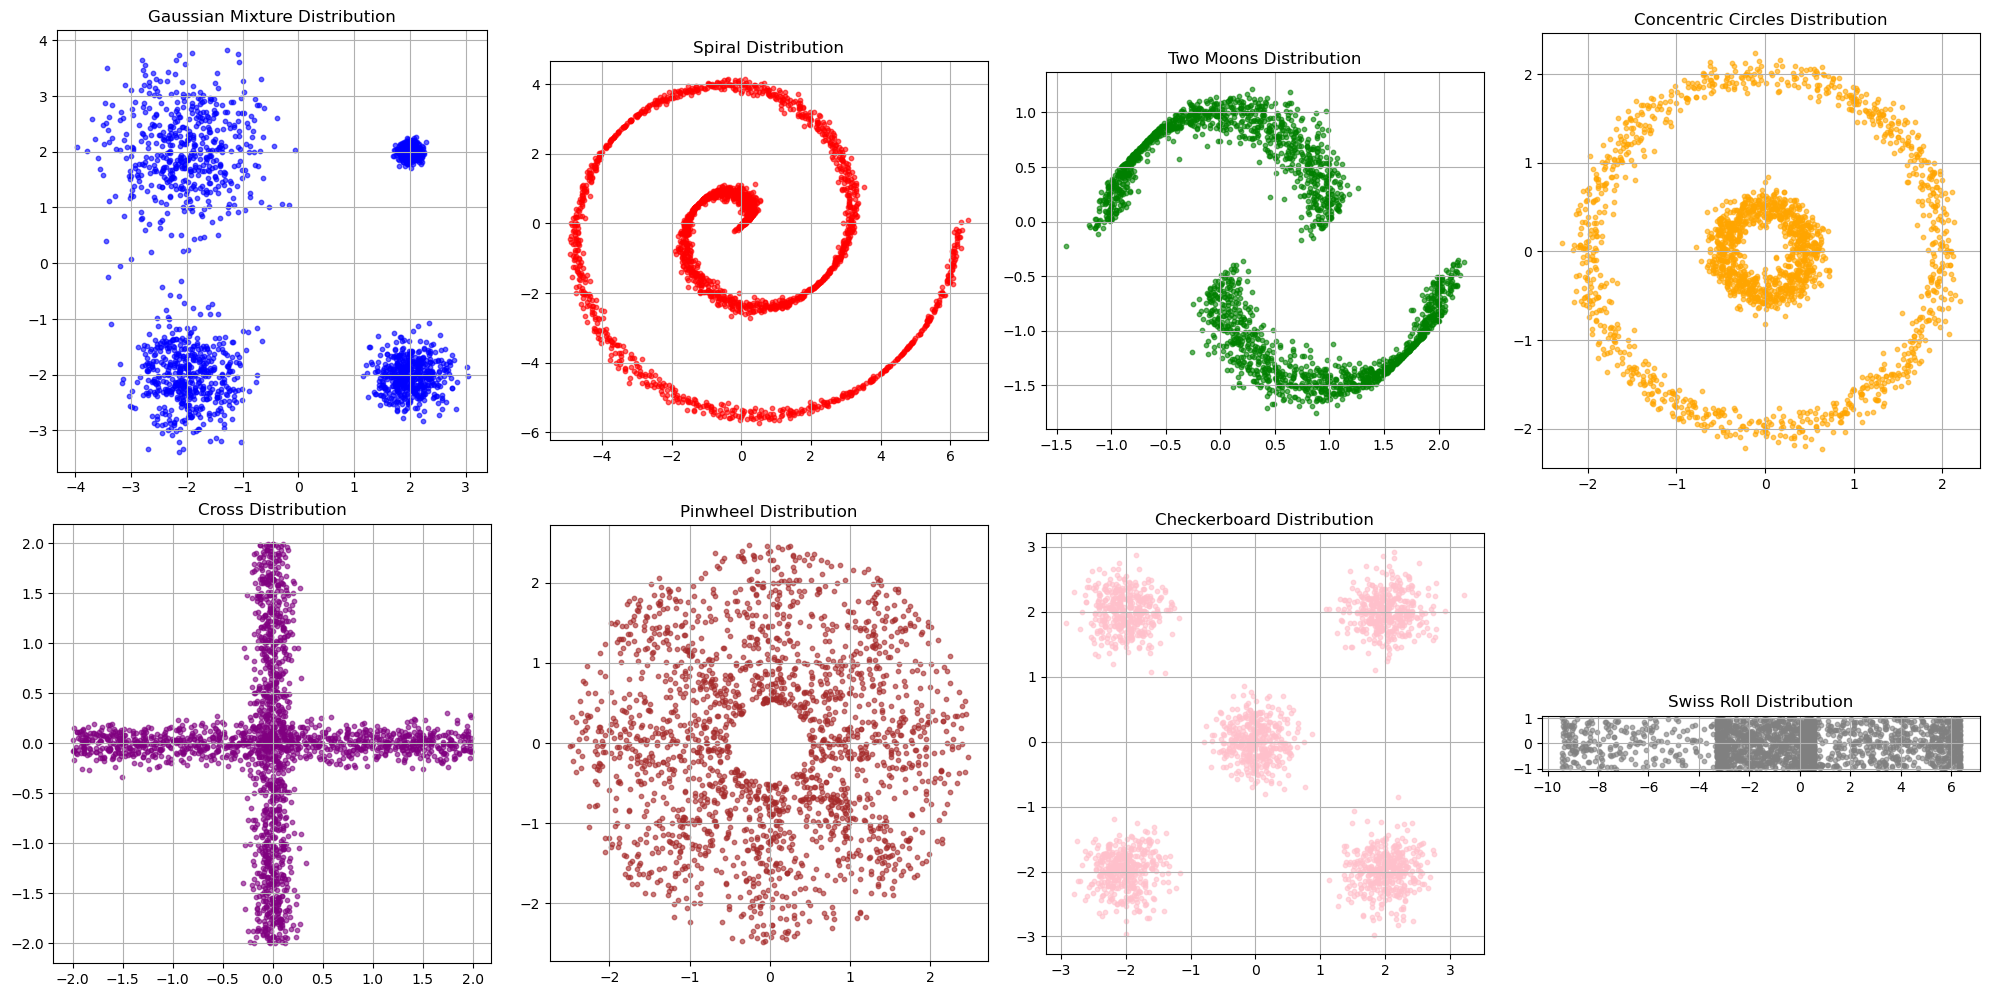

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.distributions import Beta
import copy
import math

from sampler import *
from distributions import *

visualize_target_distributions() # possible target distributions

In [ ]:
class FlowMatching:
    def __init__(self, hidden_dim=64, lr=5e-4, time_sampling='uniform', time_weighting=False, target_distribution=moons_distribution):
        
        self.lr = lr
        self.target_distribution = target_distribution
        
        # MLP for denoising
        self.network = nn.Sequential(
            nn.Linear(3, hidden_dim),  # 2D(or latent dim) + time
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(), 
            nn.Linear(hidden_dim, 2)   # 2D(or latent dim) output
        )

        self.optimizer = optim.Adam(self.network.parameters(), lr=self.lr)
        
        self.time_sampler = TimeSampler(mode=time_sampling) # time sampler when training, including 'uniform', 'beta', 'mix_unif_beta'
        self.time_weighting = time_weighting # whether to use time weighting in loss, as t -> 1, the denoising task becomes important
        
        # Best model tracking
        self.best_loss = float('inf')
        self.best_model_state = None
        
    def save_best_model(self):
        """Save current model state as the best model"""
        self.best_model_state = copy.deepcopy(self.network.state_dict())
        
    def load_best_model(self):
        """Load the best saved model state"""
        if self.best_model_state is not None:
            self.network.load_state_dict(self.best_model_state)
        else:
            print("Warning: No best model state saved yet!")
    
    def update_best_model(self, current_loss):
        """
        Compare current loss with best loss and update best model if needed.
        
        Args:
            current_loss (float): The current training loss
            
        Returns:
            bool: True if model was updated, False otherwise
        """
        if current_loss < self.best_loss - 1e-2:  # small threshold to avoid frequent updates
            self.best_loss = current_loss
            self.save_best_model()
            return True
        return False

    def generate_data(self, n_samples=2000):
        # generate samples from target distribution
        if self.target_distribution is not None:
            return self.target_distribution(n_samples)
        else:
            x1 = torch.randn(n_samples//2, 2) * 0.1 + torch.tensor([2.0, 2.0])
            x2 = torch.randn(n_samples//2, 2) * 0.5 + torch.tensor([-2.0, -2.0])
            x3 = torch.randn(n_samples//2, 2) * 0.3 + torch.tensor([2.0, -2.0])
            x4 = torch.randn(n_samples//2, 2) * 0.7 + torch.tensor([-2.0, 2.0])
            return torch.cat([x1, x2, x3, x4], dim=0)

    def create_batch(self, data, batch_size=128):
        device = next(self.network.parameters()).device
        
        idx = torch.randint(0, len(data), (batch_size,))
        x_1 = data[idx].to(device)      # sample from target distribution
        x_0 = torch.randn_like(x_1)     # noise sample from simple distribution (Gaussian)
        
        t = self.time_sampler.sample(batch_size, device) # sample time t in [0, 1] while training
        
        x_t = (1 - t) * x_0 + t * x_1   # interpolate between x_0 and x_1
        target_v = x_1 - x_0            # target best velocity to learn
        
        return x_t, t, target_v
    
    def compute_weighted_loss(self, pred_v, target_v, t):

        loss = torch.mean((pred_v - target_v) ** 2, dim=-1)  # [batch], MSE loss, based on metric space selection
        
        if self.time_weighting:
            time_weight = 1.0 / ((1.0 - t.squeeze()) ** 2 + 1e-5)   # time weighted loss
            loss = loss * time_weight                               # emphasize loss when t -> 1
            
        return loss.mean()
    
    # given input tensor and time and reference velocity, do one training step
    def train_step(self, x_t, t, target_v):

        self.optimizer.zero_grad()
        input_tensor = torch.cat([x_t, t], dim=1) # add time to input
        pred_v = self.network(input_tensor)

        # parameter update
        loss = self.compute_weighted_loss(pred_v, target_v, t)
        loss.backward()
        self.optimizer.step()
        
        return loss.item()
    
    def sample_ode(self, n_samples=500, nsteps=200, schedule_mode='uniform', use_best_model=True):
        device = next(self.network.parameters()).device
        scheduler = TimeScheduler(mode=schedule_mode)
        
        # Load best model if requested and available
        if use_best_model and self.best_model_state is not None:
            original_state = copy.deepcopy(self.network.state_dict())
            self.network.load_state_dict(self.best_model_state)
        
        self.network.eval()
        with torch.no_grad():
            x = torch.randn(n_samples, 2, device=device)
            time_schedule = scheduler.get_schedule(nsteps, p=2.0)
            trajectory = [x.clone().cpu()]
            
            for step in range(nsteps):
                t_val = time_schedule[step].item()
                dt = (time_schedule[step + 1] - time_schedule[step]).item()
                
                t = torch.full((n_samples, 1), t_val, device=device)
                input_tensor = torch.cat([x, t], dim=1)
                v = self.network(input_tensor)
                
                # Euler
                x = x + v * dt
                trajectory.append(x.clone().cpu())
        
        # Restore original model state if we loaded best model
        if use_best_model and self.best_model_state is not None:
            self.network.load_state_dict(original_state)
                
        return x.cpu(), torch.stack(trajectory)
    
    def sample_sde(self, n_samples=500, nsteps=200, schedule_mode='uniform', noise_scale=0.1, use_best_model=True):
        device = next(self.network.parameters()).device
        scheduler = TimeScheduler(mode=schedule_mode)

        # Load best model if requested and available
        if use_best_model and self.best_model_state is not None:
            original_state = copy.deepcopy(self.network.state_dict())
            self.network.load_state_dict(self.best_model_state)

        self.network.eval()
        with torch.no_grad():
            x = torch.randn(n_samples, 2, device=device)          # sample from noise distribution
            time_schedule = scheduler.get_schedule(nsteps, p=2.0) # get time schedule when denoising
            trajectory = [x.clone().cpu()]
            
            for step in range(nsteps):
                t_val = time_schedule[step].item()
                dt = (time_schedule[step + 1] - time_schedule[step]).item()
                t = torch.full((n_samples, 1), t_val, device=device)

                input_tensor = torch.cat([x, t], dim=1)
                v = self.network(input_tensor)
                
                if t_val > 0.95:  # using ode when reaching t -> 1, do not introduce noise to final step
                    x = x + v * dt
                else:
                    # sde update
                    score = vf_to_score(x, v, t)
                    gt = 1.0 / (t_val + 0.01)

                    deterministic = (v + gt * score) * dt
                    noise = torch.randn_like(x) * math.sqrt(2 * gt * noise_scale * dt)
                    x = x + deterministic + noise
                    
                trajectory.append(x.clone().cpu())
        
        # Restore original model state if we loaded best model
        if use_best_model and self.best_model_state is not None:
            self.network.load_state_dict(original_state)
                
        return x.cpu(), torch.stack(trajectory)
    
    def train(self, n_epochs=2000):
        data = self.generate_data()
        losses = []
        
        for epoch in range(n_epochs):
            x_t, t, target_v = self.create_batch(data)
            loss = self.train_step(x_t, t, target_v)
            losses.append(loss)
            
            # Update best model if current loss is better
            if self.update_best_model(loss):
                if epoch % 100 == 0:  # Only print when we also print regular progress
                    print(f"  → New best model saved! Loss: {loss:.4f}")
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
                
        return losses
    
    def visualize_comparison(self):

        data = self.generate_data()

        samples_ode_uniform, traj_uniform = self.sample_ode(n_samples=500, schedule_mode='uniform')
        samples_ode_log, traj_log = self.sample_ode(n_samples=500, schedule_mode='log')
        samples_ode_pow, traj_pow = self.sample_ode(n_samples=500, schedule_mode='power')

        samples_sde_uniform, traj_sde_uniform = self.sample_sde(n_samples=500)
        samples_sde_log, traj_sde_log = self.sample_sde(n_samples=500, schedule_mode='log')
        samples_sde_pow, traj_sde_pow = self.sample_sde(n_samples=500, schedule_mode='power')
        
        fig, axes = plt.subplots(3, 3, figsize=(18, 12))
        
        axes[0,0].scatter(data[:, 0], data[:, 1], alpha=0.6, s=20, c='blue')
        axes[0,0].set_title("Target Distribution")
        axes[0,0].grid(True)
        
        axes[0,1].scatter(samples_ode_uniform[:, 0], samples_ode_uniform[:, 1], alpha=0.6, s=20, c='red')
        axes[0,1].set_title("ODE Sampling (Uniform Schedule)")
        axes[0,1].grid(True)
        
        axes[0,2].scatter(samples_sde_uniform[:, 0], samples_sde_uniform[:, 1], alpha=0.6, s=20, c='green')
        axes[0,2].set_title("SDE Sampling (Uniform Schedule)")
        axes[0,2].grid(True)
        
        axes[1,0].scatter(data[:, 0], data[:, 1], alpha=0.6, s=20, c='orange')
        axes[1,0].set_title("Target Distribution")
        axes[1,0].grid(True)

        axes[1,1].scatter(samples_ode_log[:, 0], samples_ode_log[:, 1], alpha=0.6, s=20, c='purple')
        axes[1,1].set_title("ODE Sampling (Log Schedule)")
        axes[1,1].grid(True)

        axes[1,2].scatter(samples_sde_log[:, 0], samples_sde_log[:, 1], alpha=0.6, s=20, c='brown')
        axes[1,2].set_title("SDE Sampling (Log Schedule)")
        axes[1,2].grid(True)

        axes[2,0].scatter(data[:, 0], data[:, 1], alpha=0.6, s=20, c='cyan')
        axes[2,0].set_title("Target Distribution")
        axes[2,0].grid(True)
        
        axes[2,1].scatter(samples_ode_pow[:, 0], samples_ode_pow[:, 1], alpha=0.6, s=20, c='magenta')
        axes[2,1].set_title("ODE Sampling (Power Schedule)")
        axes[2,1].grid(True)
        
        axes[2,2].scatter(samples_sde_pow[:, 0], samples_sde_pow[:, 1], alpha=0.6, s=20, c='lime')
        axes[2,2].set_title("SDE Sampling (Power Schedule)")
        axes[2,2].grid(True)

        plt.tight_layout()
        plt.show()
    
    def visualize_time_sampling(self, n_samples=10000):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        sampler_uniform = TimeSampler('uniform')
        t_uniform = sampler_uniform.sample(n_samples).squeeze().numpy()
        
        sampler_beta = TimeSampler('beta')
        t_beta = sampler_beta.sample(n_samples).squeeze().numpy()

        sampler_mix = TimeSampler('mix_unif_beta')
        t_mix = sampler_mix.sample(n_samples).squeeze().numpy()
        
        axes[0].hist(t_uniform, bins=50, alpha=0.7, density=True)
        axes[0].set_title("Uniform Sampling")
        axes[0].set_xlabel("t")
        axes[0].set_ylabel("Density")
        
        axes[1].hist(t_beta, bins=50, alpha=0.7, density=True)
        axes[1].set_title("Beta(1.5, 1.5) Sampling")
        axes[1].set_xlabel("t")
        
        axes[2].hist(t_mix, bins=50, alpha=0.7, density=True)
        axes[2].set_title("Mixed Uniform-Beta Sampling")
        axes[2].set_xlabel("t")
        
        plt.tight_layout()
        plt.show()

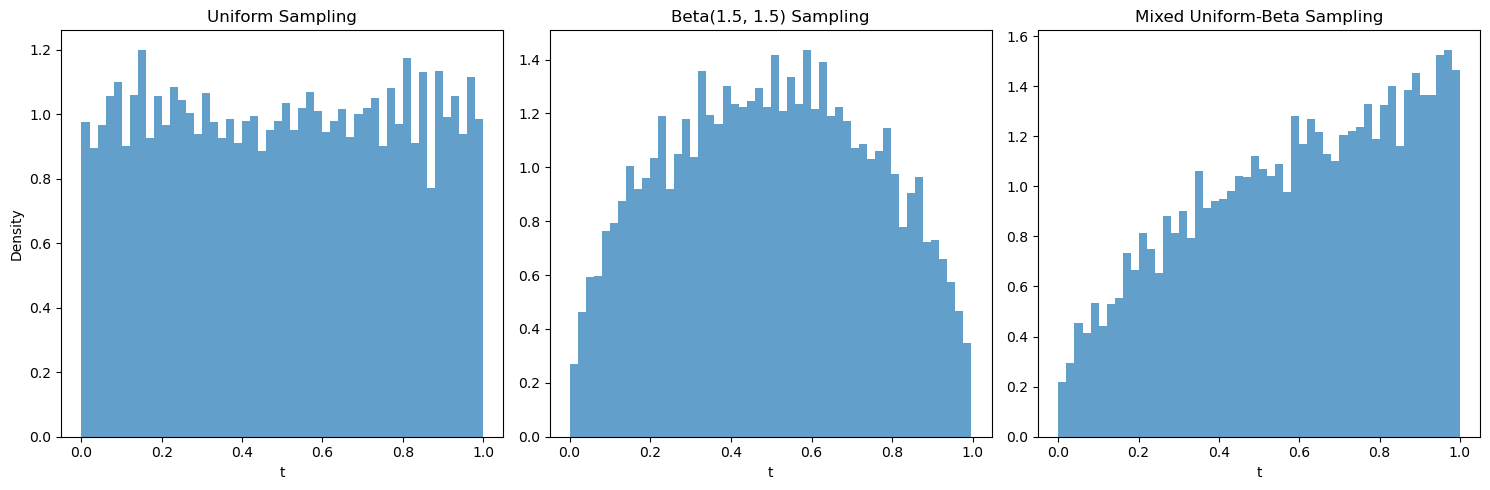

In [3]:
demo_fm = FlowMatching(time_weighting=False)
demo_fm.visualize_time_sampling()

Using device: mps
  → New best model saved! Loss: 1.7922
Epoch 0, Loss: 1.7922
Epoch 100, Loss: 1.5875
Epoch 200, Loss: 1.2858
Epoch 300, Loss: 1.3132
Epoch 400, Loss: 1.2300
Epoch 500, Loss: 1.2039
Epoch 600, Loss: 1.2189
Epoch 700, Loss: 1.3020
Epoch 800, Loss: 1.2441
Epoch 900, Loss: 1.0578
Epoch 1000, Loss: 1.3076
Epoch 1100, Loss: 1.0706
Epoch 1200, Loss: 1.2336
Epoch 1300, Loss: 1.2459
Epoch 1400, Loss: 1.2922
Epoch 1500, Loss: 1.1618
Epoch 1600, Loss: 1.3807
Epoch 1700, Loss: 1.1278
Epoch 1800, Loss: 1.2241
Epoch 1900, Loss: 1.3361
  → New best model saved! Loss: 1.6711
Epoch 0, Loss: 1.6711
Epoch 100, Loss: 1.5977
Epoch 200, Loss: 1.4028
Epoch 300, Loss: 1.3406
Epoch 400, Loss: 1.2800
Epoch 500, Loss: 1.3255
Epoch 600, Loss: 1.3537
Epoch 700, Loss: 1.4580
Epoch 800, Loss: 1.3491
Epoch 900, Loss: 1.2462
Epoch 1000, Loss: 1.2350
Epoch 1100, Loss: 1.4054
Epoch 1200, Loss: 1.1836
Epoch 1300, Loss: 1.3440
Epoch 1400, Loss: 1.3485
Epoch 1500, Loss: 1.1184
Epoch 1600, Loss: 1.0403
Epo

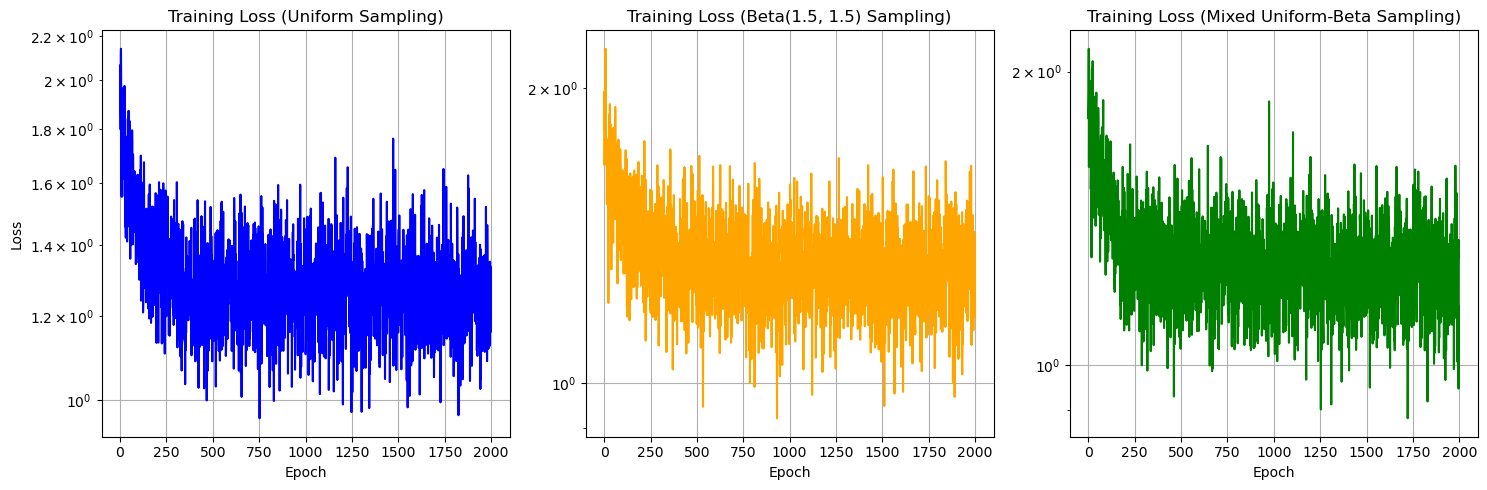

In [4]:
fm_mixed = FlowMatching(
    hidden_dim=128, 
    time_sampling='mix_unif_beta',  
    time_weighting=False             
)

fm_beta = FlowMatching(
    hidden_dim=128, 
    time_sampling='beta',  
    time_weighting=False             
)

fm_uniform = FlowMatching(
    hidden_dim=128, 
    time_sampling='uniform',
    time_weighting=False
)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
fm_mixed.network.to(device)
fm_beta.network.to(device)
fm_uniform.network.to(device)
print(f"Using device: {device}")

fm_mixed_losses = fm_mixed.train(n_epochs=2000)
fm_beta_losses = fm_beta.train(n_epochs=2000)
fm_uniform_losses = fm_uniform.train(n_epochs=2000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(fm_uniform_losses, label='Uniform', color='blue')
axes[0].set_title("Training Loss (Uniform Sampling)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_yscale('log')

axes[1].plot(fm_beta_losses, label='Beta(1.5, 1.5)', color='orange')
axes[1].set_title("Training Loss (Beta(1.5, 1.5) Sampling)")
axes[1].set_xlabel("Epoch")
axes[1].set_yscale('log')

axes[2].plot(fm_mixed_losses, label='Mixed', color='green')
axes[2].set_title("Training Loss (Mixed Uniform-Beta Sampling)")
axes[2].set_xlabel("Epoch")
axes[2].set_yscale('log')

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()


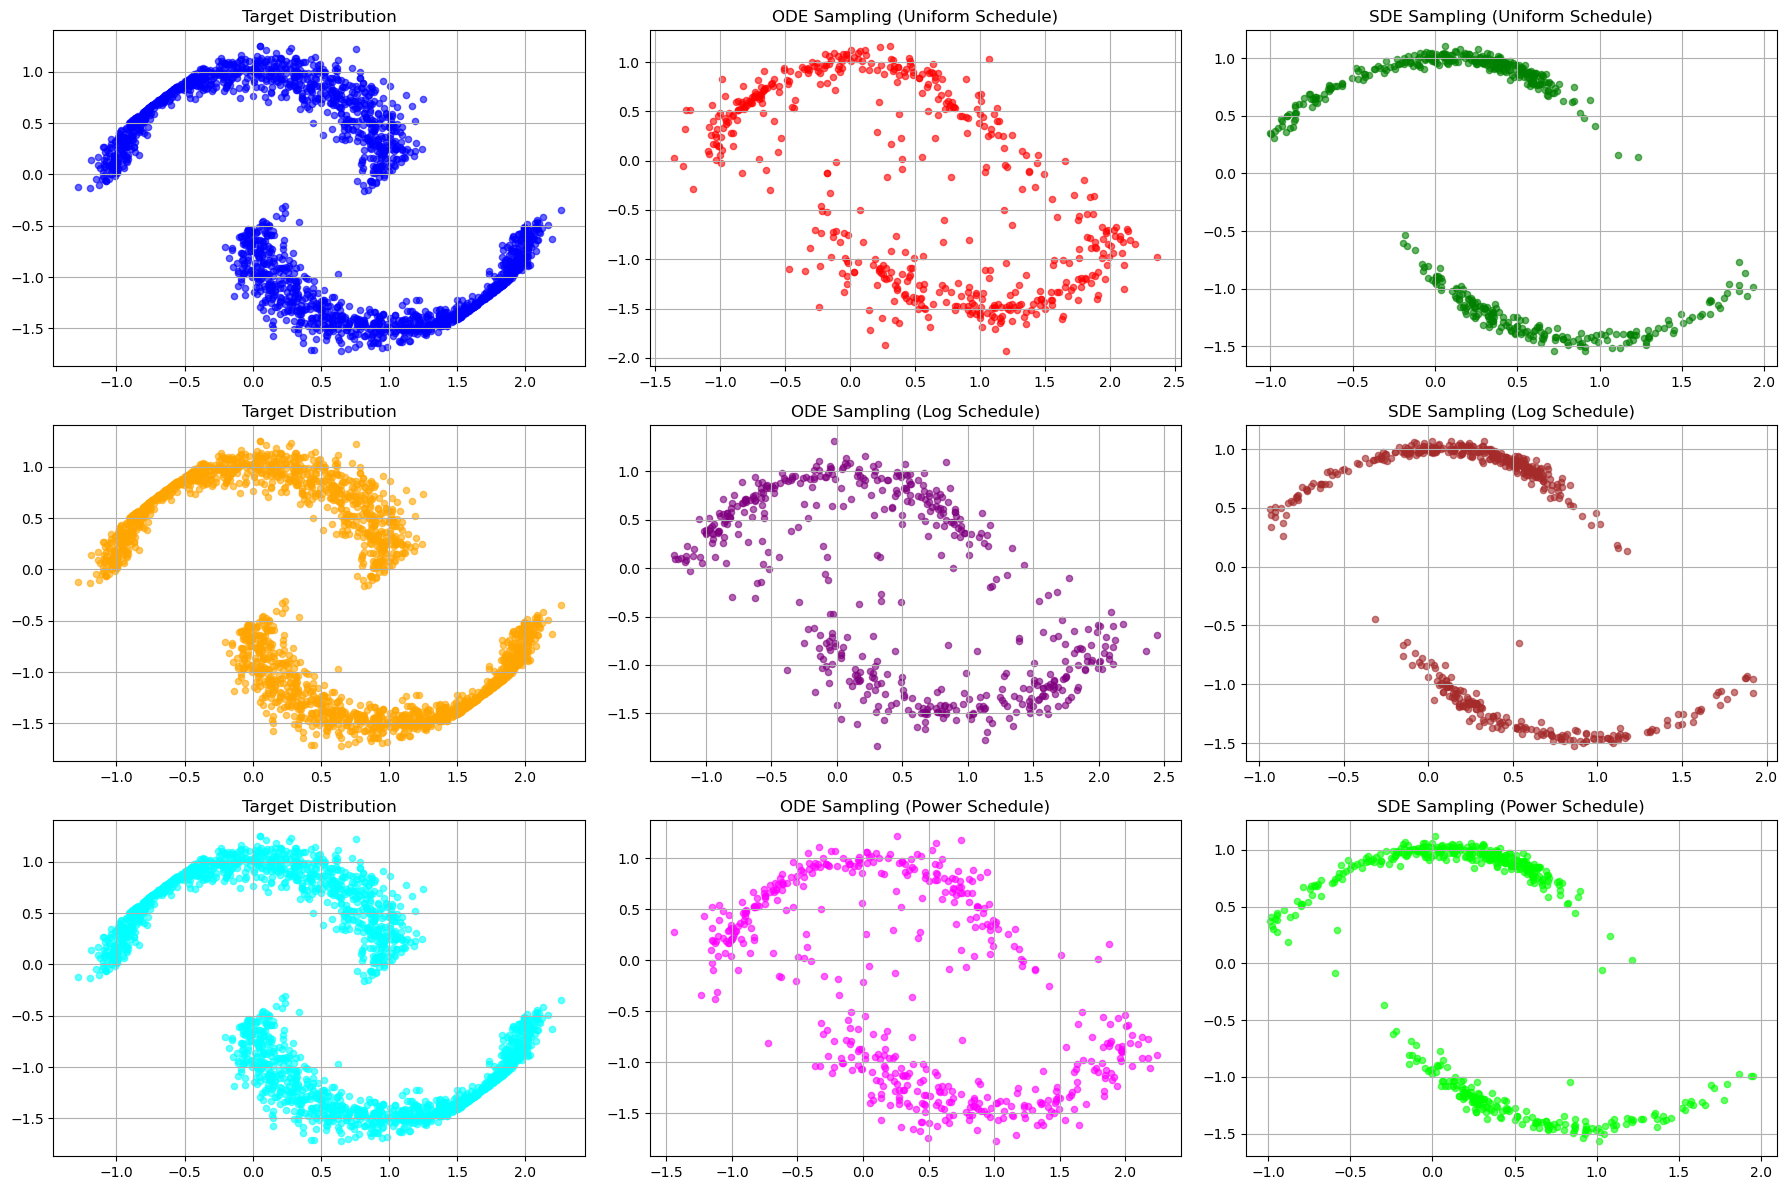

In [6]:
import copy
fm_mixed.visualize_comparison()

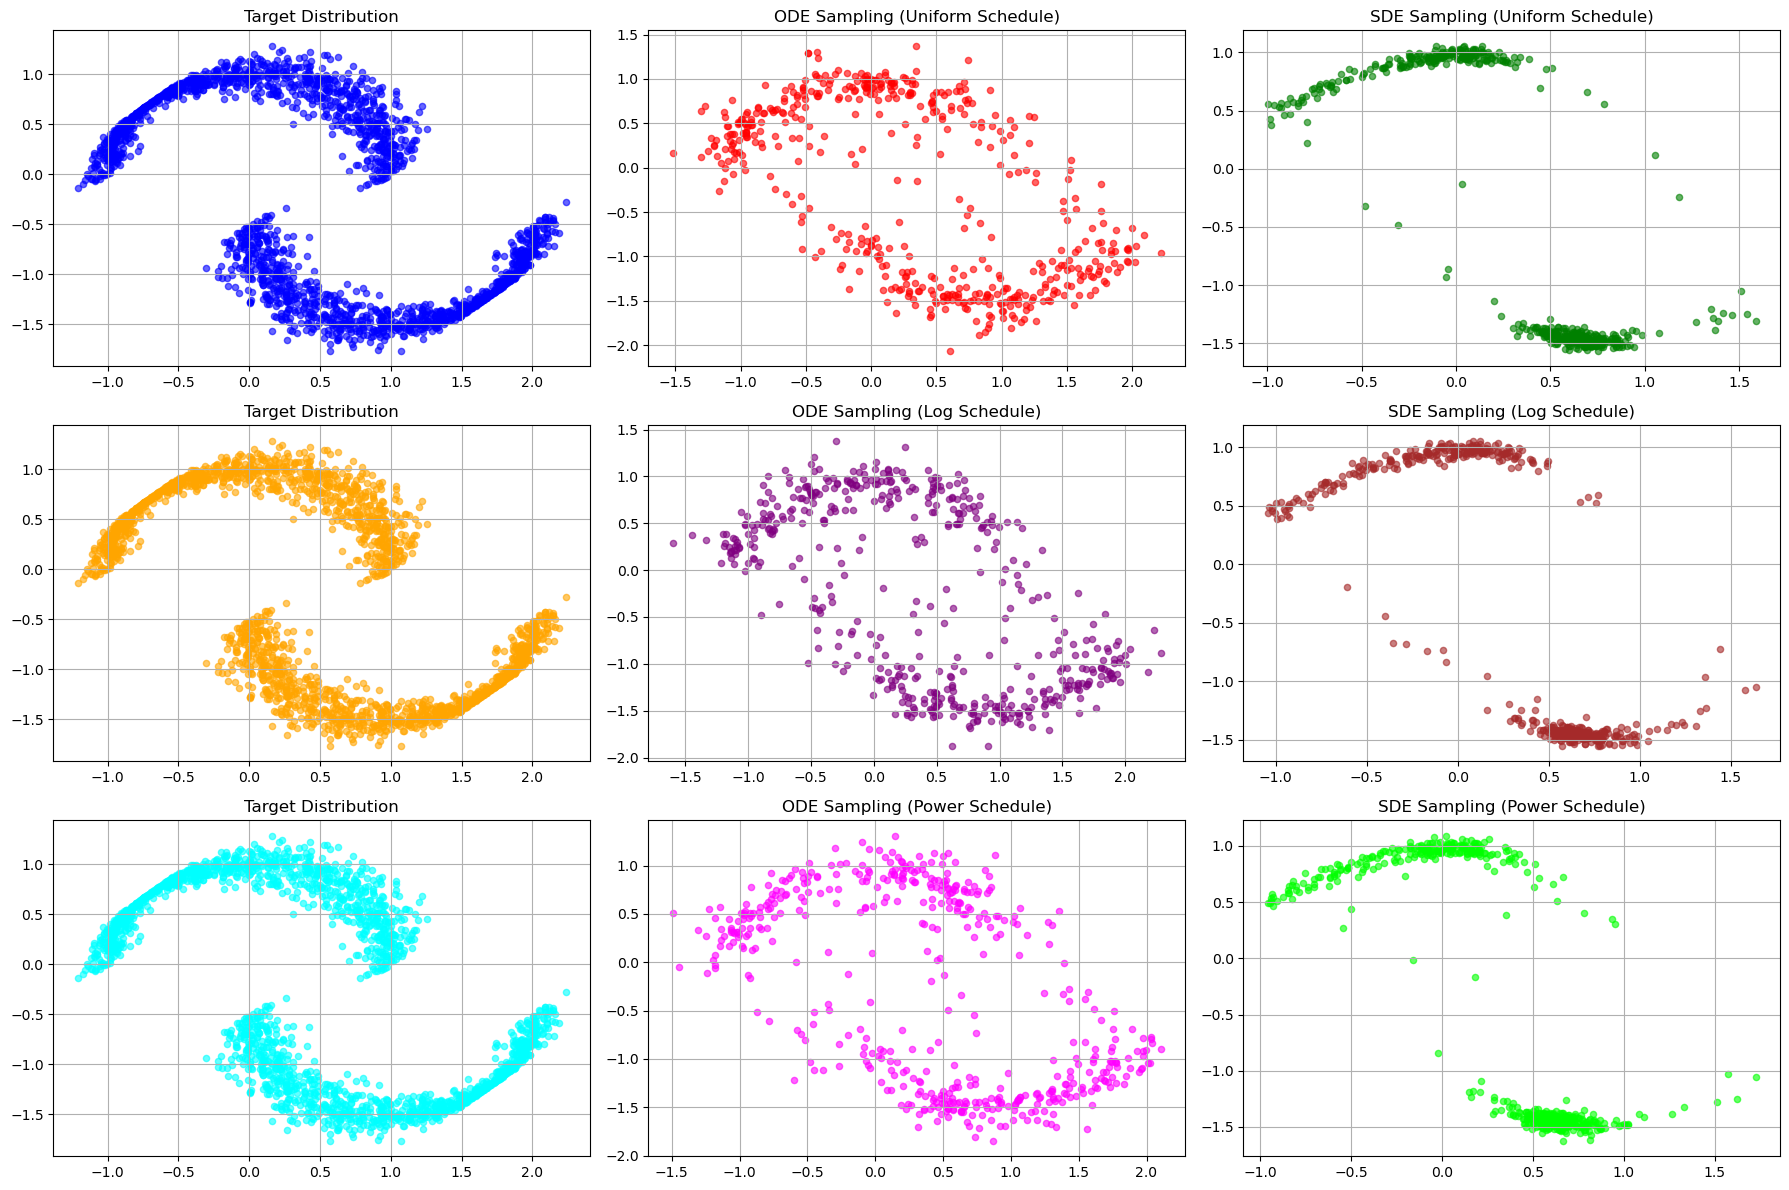

In [7]:
fm_beta.visualize_comparison()

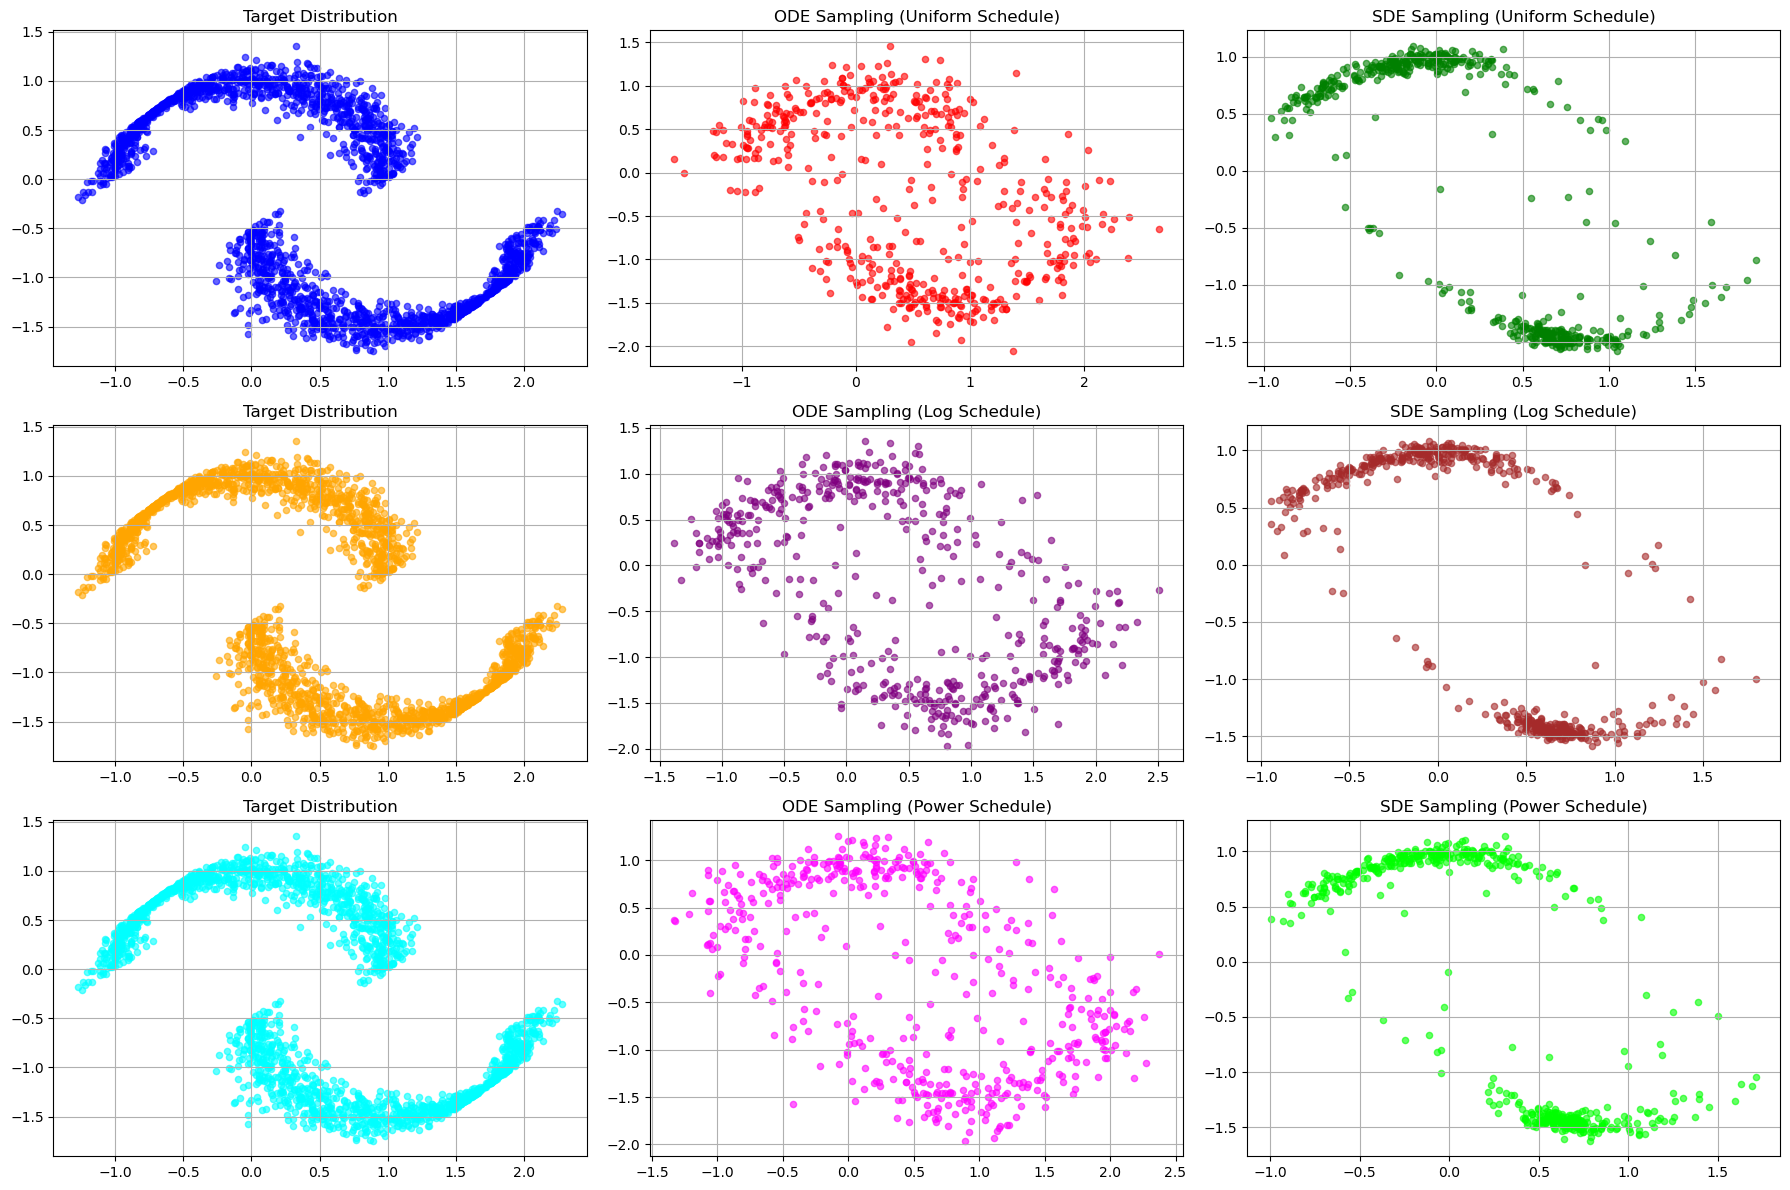

In [8]:
fm_uniform.visualize_comparison()

Testing best model saving functionality...
Training with best model tracking:
  → New best model saved! Loss: 2.2419
Epoch 0, Loss: 2.2419
Epoch 100, Loss: 1.9576
Epoch 200, Loss: 1.5663
Epoch 300, Loss: 1.3556
Epoch 400, Loss: 1.2540

Final training loss: 1.1621
Best saved loss: 1.0537
Best model state saved: True

Comparing sampling results...


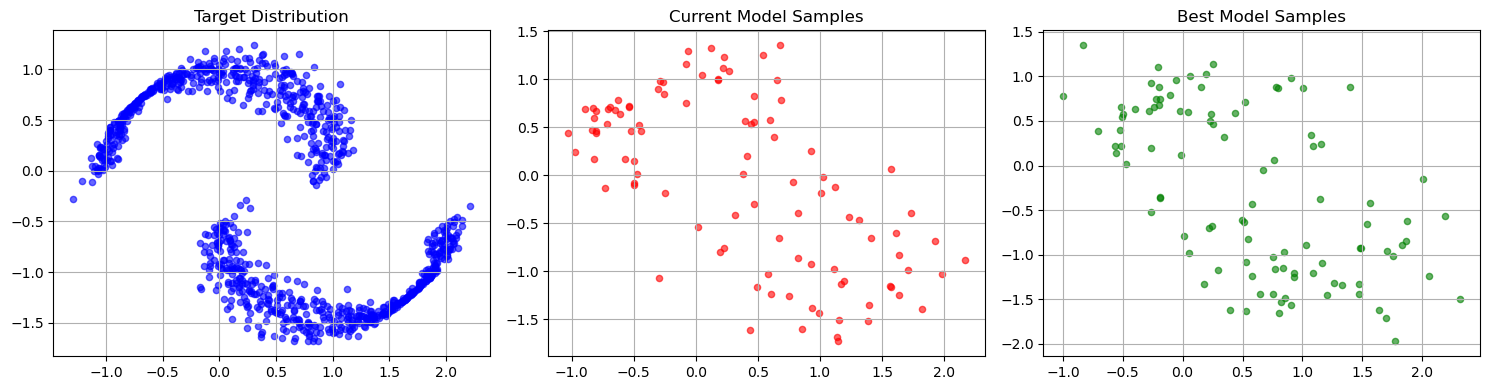

✓ Best model functionality test completed!


In [9]:
# Test the new best model saving functionality
print("Testing best model saving functionality...")

# Create a small test model
test_fm = FlowMatching(hidden_dim=32, time_sampling='uniform')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
test_fm.network.to(device)

# Train for a short period to see the best model tracking in action
print("Training with best model tracking:")
test_losses = test_fm.train(n_epochs=500)

print(f"\nFinal training loss: {test_losses[-1]:.4f}")
print(f"Best saved loss: {test_fm.best_loss:.4f}")
print(f"Best model state saved: {test_fm.best_model_state is not None}")

# Compare sampling with current model vs best model
print("\nComparing sampling results...")
samples_current, _ = test_fm.sample_ode(n_samples=100, use_best_model=False)
samples_best, _ = test_fm.sample_ode(n_samples=100, use_best_model=True)

# Visualize the difference
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target data
data = test_fm.generate_data(1000)
axes[0].scatter(data[:, 0], data[:, 1], alpha=0.6, s=20, c='blue')
axes[0].set_title("Target Distribution")
axes[0].grid(True)

# Current model samples
axes[1].scatter(samples_current[:, 0], samples_current[:, 1], alpha=0.6, s=20, c='red')
axes[1].set_title("Current Model Samples")
axes[1].grid(True)

# Best model samples
axes[2].scatter(samples_best[:, 0], samples_best[:, 1], alpha=0.6, s=20, c='green')
axes[2].set_title("Best Model Samples")
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("✓ Best model functionality test completed!")